In [ ]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

In [60]:
out_dir = Path("/home/lacrio/ML-Glacier-SMB-SEB/outputs")

dir_figures = out_dir / "figures"

filename = '/home/lacrio/DATA/CB/pros/netcdf/SMB_simulated_Shallap.nc'
ds_xgb = xr.open_dataset(filename)
filename = '/home/lacrio/DATA/CB/pros/Shallap_geodata_mb_monthly.nc'
ds_cpy = xr.open_dataset(filename)

In [ ]:

# --- Select period ---
t_slice = slice("2022-01-01", "2022-12-01")

mb_cosipy = ds_cpy["MB"].sel(time=t_slice).mean("time")
mb_xgb    = ds_xgb["SMB_mean"].sel(time=t_slice).mean("time")

mb_diff = mb_cosipy - mb_xgb


In [63]:
vmax = np.nanmax(np.abs([
    mb_cosipy.values,
    mb_xgb.values
]))

vmax_diff = np.nanmax(np.abs(mb_diff.values))


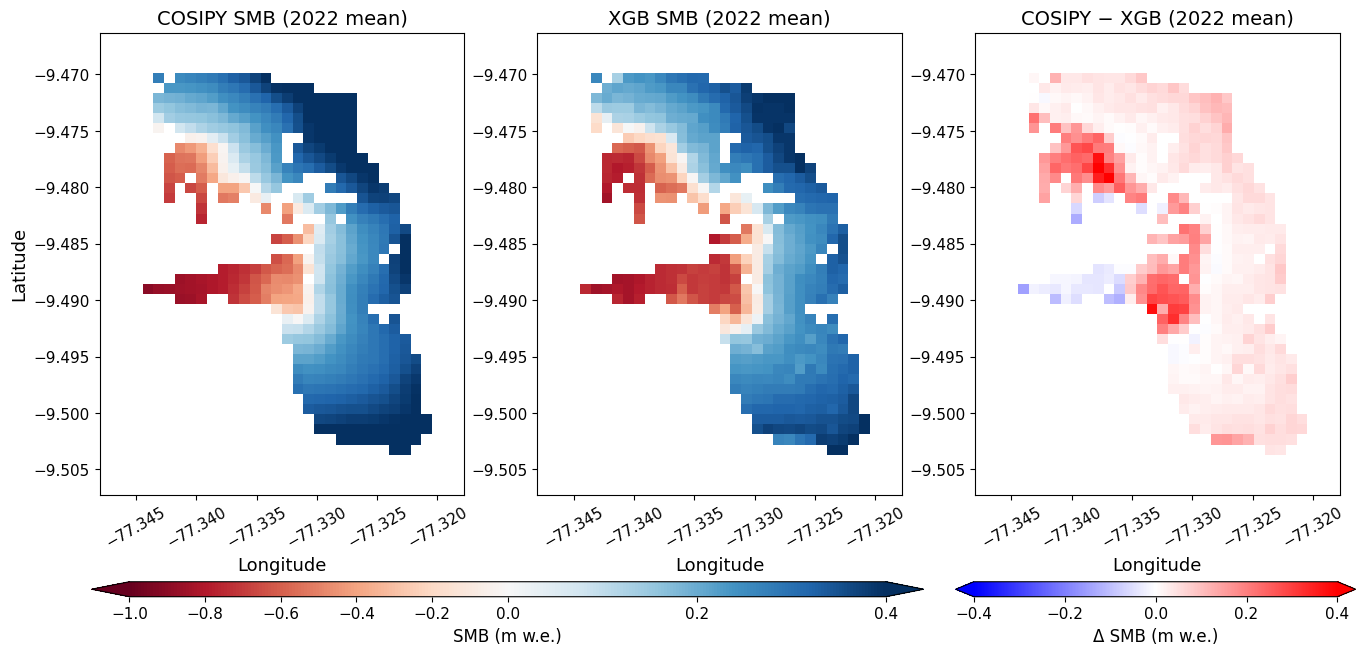

In [ ]:
# ======================================================
# Color settings
# ======================================================
vmin = -1.0
vmax =  0.4

norm_smb = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

vmax_diff = 0.4
norm_diff = colors.TwoSlopeNorm(vmin=-vmax_diff, vcenter=0.0, vmax=vmax_diff)

# ======================================================
# Figure
# ======================================================
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(16, 6),
    constrained_layout=False
)

label_fs = 13
tick_fs  = 11
title_fs = 14
cbar_fs  = 12

# ======================================================
# COSIPY
# ======================================================
p0 = axes[0].pcolormesh(
    mb_cosipy.lon, mb_cosipy.lat, mb_cosipy,
    cmap="RdBu",
    norm=norm_smb,
    shading="auto"
)
axes[0].set_title("COSIPY SMB (2022 mean)", fontsize=title_fs)
axes[0].set_xlabel("Longitude", fontsize=label_fs)
axes[0].set_ylabel("Latitude", fontsize=label_fs)

axes[0].tick_params(axis="both", labelsize=tick_fs)
axes[0].tick_params(axis="x", rotation=30)

# ======================================================
# XGB
# ======================================================
p1 = axes[1].pcolormesh(
    mb_xgb.lon, mb_xgb.lat, mb_xgb,
    cmap="RdBu",
    norm=norm_smb,
    shading="auto"
)
axes[1].set_title("XGB SMB (2022 mean)", fontsize=title_fs)
axes[1].set_xlabel("Longitude", fontsize=label_fs)

axes[1].tick_params(axis="both", labelsize=tick_fs)
axes[1].tick_params(axis="x", rotation=30)

# ======================================================
# Shared colorbar (COSIPY + XGB)
# ======================================================
cax1 = fig.add_axes([0.12, -0.06, 0.52, 0.025])

cbar1 = fig.colorbar(
    p0,
    cax=cax1,
    orientation="horizontal",
    extend="both"
)
cbar1.set_label("SMB (m w.e.)", fontsize=cbar_fs)
cbar1.set_ticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4])
cbar1.ax.tick_params(labelsize=tick_fs)

# ======================================================
# Difference
# ======================================================
p2 = axes[2].pcolormesh(
    mb_diff.lon, mb_diff.lat, mb_diff,
    cmap="bwr",
    norm=norm_diff,
    shading="auto"
)
axes[2].set_title("COSIPY − XGB (2022 mean)", fontsize=title_fs)
axes[2].set_xlabel("Longitude", fontsize=label_fs)

axes[2].tick_params(axis="both", labelsize=tick_fs)
axes[2].tick_params(axis="x", rotation=30)

# ======================================================
# Colorbar (Difference)
# ======================================================
cax2 = fig.add_axes([0.66, -0.06, 0.25, 0.025])

cbar2 = fig.colorbar(
    p2,
    cax=cax2,
    orientation="horizontal",
    extend="both"
)
cbar2.set_label("Δ SMB (m w.e.)", fontsize=cbar_fs)
cbar2.ax.tick_params(labelsize=tick_fs)

plt.show()
fig.savefig(dir_figures / "SMB_Shallap_2022.png", dpi=300, facecolor="w",
    bbox_inches="tight", pad_inches=0.1
)

